## Intro
Deterministic approaches are fundamentally **greedy**, meaning they only step downhill. In non-convex cases with multiple local minima, it is guaranteed to get trapped in the nearest local valley.
**Stochastic optimization** escapes local traps by injecting controlled randomness into search decisions.

## Simulated Annealing

**Physical Annealing Analogy** - in metallurgy, a metal is heated to a liquid state (with high energy, atoms move randomly) and cooled slowely (*annealed*). Slow cooling allows atoms to organize into a defect-free, minimum-energy crystal lattice. Coolint too fast (*quenching*) freezes defects into the structure (local minima)

- The objective function we want to minimize is called the **energy function** $$E(x) \equiv f(x)$$
- To control the rate of exploration we use the **Temperature Parameter $T > 0$**
    - High $T$: The algorithm easily climbs uphill
    - Low $T$: Greedy exploitation - the algorithm behaves almost identically to standard gradient descent.
- The **inverse temperature**: $$\lambda = \frac{1}{T}$$
    - High Temperature $T \to \infty \implies \lambda \to 0$
    - Freezing Temperature $T \to 0 \implies \lambda \to \infty$
- The **Normalizing Constant $A_{\lambda}$**: $$A_\lambda = \frac{1}{\displaystyle\int \exp\big(-\lambda E(\mathbf{x})\big) \, d\mathbf{x}} = \frac{1}{Z(\lambda)}$$ The integral in the denominator includes the factor $\lambda$, making $A_\lambda$ ensure the total area under $f(\mathbf{x}, \lambda)$ integrates to exactly 1.
- At any fixed temperature $T$, the probability of the system occupying state $\mathbf{x}$ follows the **Gibbs/Boltzmann Distribution**: $$f(\mathbf{x}, \lambda) = A_\lambda \exp\big(-\lambda E(\mathbf{x})\big) = \frac{\exp\big(-\lambda E(\mathbf{x})\big)}{\displaystyle\int \exp\big(-\lambda E(\mathbf{x}')\big) \, d\mathbf{x}'}$$
- As the temperature approaches zero, the continuous probability distribution collapses into a uniform mass concentrated exclusively on the **global minimum**. $$\lim_{T \to 0^+} \pi_T(\mathbf{x}) = \begin{cases} \frac{1}{\vert{}\mathcal{X}^*\vert{}}, & \text{if } \mathbf{x} \in \mathcal{X}^* \text{ (the global minima)} \\ 0, & \text{otherwise} \end{cases}$$

The lowest point (global minimum) of $E(\mathbf{x})$ corresponds directly to the tallest spike (global maximum/mode) of $f(\mathbf{x}, \lambda)$:$$\arg\min_{\mathbf{x}} E(\mathbf{x}) \equiv \arg\max_{\mathbf{x}} f(\mathbf{x}, \lambda)$$

### The core mechanism
At iteration $k$ with temperature $T$, the system proposes a neighboring state $\mathbf{x}^* \sim q(\mathbf{x}^* \mid \mathbf{x})$.

Compute the energy difference: $$\Delta E = E(\mathbf{x}^*) - E(\mathbf{x})$$ The probability of accepting candidate $\mathbf{x}^*$ is given by the **Metropolis acceptance probability:** $$\alpha(\mathbf{x} \to \mathbf{x}^*) = \begin{cases} 1, & \text{if } \Delta E \le 0 \quad \text{(Downhill move: ALWAYS accepted)} \\ \exp\left(-\lambda  {\Delta E}\right), & \text{if } \Delta E > 0 \quad \text{(Uphill move: conditionally accepted)} \end{cases}$$
In compact form: $$\alpha = \min\left(1, \, \exp\left(-\lambda {\Delta E}\right)\right)$$
- If a move reduces energy ($\Delta E < 0$), accept it unconditionally.
- If a move increases energy ($\Delta E > 0$), accept it with probability $P = \exp(-\lambda \Delta E) \in (0, 1)$. This uphill acceptance is the exact mechanism that enables escaping local minima.

### Step-by-step Simulated Annealing Algorithm
1. Initialization:
    - Choose an initial state $\mathbf{x_0}$
    - Set initial temperature $T_0$ sufficiently high (so acceptance rate $\approx 80%$)
    - Set iteration counter $k = 0$.
2. While $T > T_{min}$ and stopping criteria are unmet:
    - Repeat for $L$ steps (chain length/epoch):
        - Generate candidate $\mathbf{x}^* \sim q(\mathbf{x}^* \mid \mathbf{x})$.
        - Compute $\Delta E = E(\mathbf{x}^*) - E(\mathbf{x})$.
        - If $\Delta E \le 0$:$$\mathbf{x} \leftarrow \mathbf{x}^*$$
        - Else ($\Delta E > 0$):
            - Draw random float $u \sim \text{Uniform}(0, 1)$.
            - If $u < \exp(-\Delta E / T)$: $$\mathbf{x} \leftarrow \mathbf{x}^*$$
    - Update temperature according tp schedule: $$T \leftarrow \text{Cool}(T)$$

3. Returen the best state visited $\mathbf{x_{best}}$

### Annealing Schedules
The rate at which $T$ decreases determines whether the algorithm finds the global minimum or gets trapped:

- **Logarithmic (Geman & Geman)**: $T_k = \frac{T_0}{ln(1 + k)}$; Provably converges to the global minimum with probability 1, but impractically slow in real-world engineering.
- **Geometric (exponential)**: $T_{k+1} = \alpha T_k \quad (\alpha \in [0.85, 0.99])$; The practical standard. Drops temperature quickly while preserving near-equilibrium states.
- **Linear**: $T_k = T_0 - \beta k$; Decreases temperature at a constant rate; risk of premature freezing in complex landscapes.

## Code example

Initial State:  x = +4.2000 | f(x) = 24.5498
Optimal Found:  x = -0.0000 | f(x) = 0.000000
Target Global:  x = +0.0000 | f(x) = 0.000000


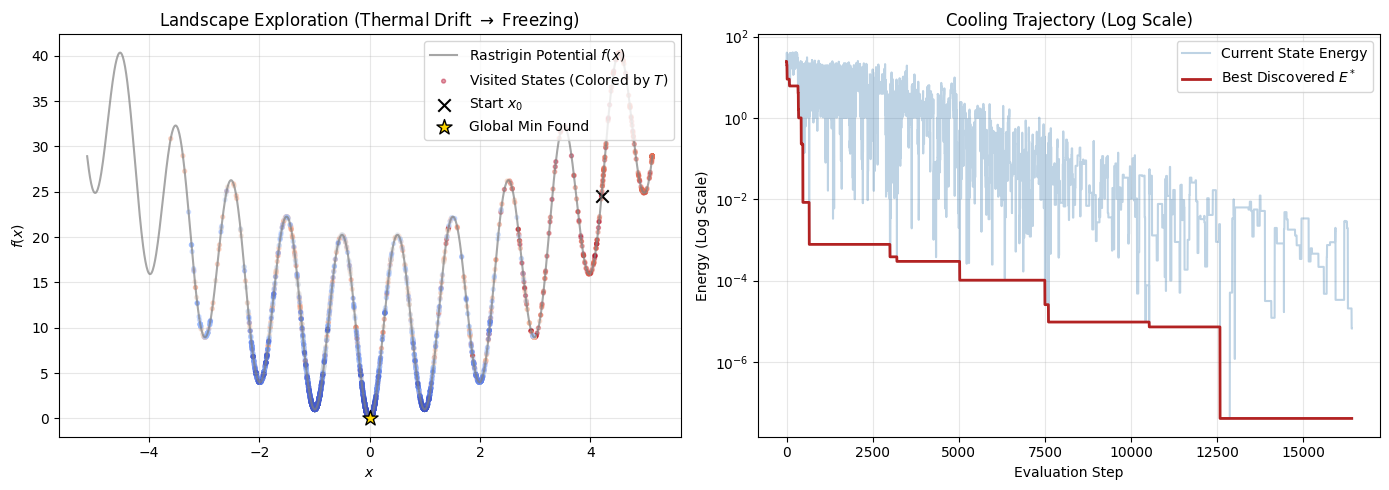

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rastrigin_1d(x):
    """
    1D Rastrigin function: highly multimodal with many deceptive local minima.
    Global minimum is at x* = 0 with f(x*) = 0.
    """
    A = 10.0
    return A + (x**2 - A * np.cos(2.0 * np.pi * x))

def simulated_annealing(
    cost_func,
    x_init=4.2,
    t_start=15.0,
    t_min=1e-4,
    cooling_rate=0.985,
    steps_per_temp=30,
    step_size=0.35,
    domain=(-5.12, 5.12),
    seed=42
):
    """
    Simulated Annealing algorithm for 1D global optimization.
    """
    np.random.seed(seed)
    
    # State tracking
    current_x = np.clip(x_init, domain[0], domain[1])
    current_energy = cost_func(current_x)
    
    best_x = current_x
    best_energy = current_energy
    
    current_t = t_start
    history = {
        'x': [current_x],
        'energy': [current_energy],
        'best_energy': [best_energy],
        'temperature': [current_t]
    }
    
    # Outer annealing loop
    while current_t > t_min:
        # Inner equilibrium loop (Markov chain at fixed T)
        for _ in range(steps_per_temp):
            # Propose candidate jump from symmetric Gaussian kernel
            proposal_x = current_x + np.random.normal(0.0, step_size)
            proposal_x = np.clip(proposal_x, domain[0], domain[1])
            proposal_energy = cost_func(proposal_x)
            
            # Energy delta
            delta_e = proposal_energy - current_energy
            
            # Metropolis acceptance criterion:
            # - delta_e <= 0: accept automatically (uphill move avoided)
            # - delta_e > 0: accept conditionally with probability exp(-delta_e / T)
            if delta_e <= 0.0 or np.random.uniform(0.0, 1.0) < np.exp(-delta_e / current_t):
                current_x = proposal_x
                current_energy = proposal_energy
                
                # Track global best visited so far
                if current_energy < best_energy:
                    best_x = current_x
                    best_energy = current_energy
            
            history['x'].append(current_x)
            history['energy'].append(current_energy)
            history['best_energy'].append(best_energy)
            history['temperature'].append(current_t)
            
        # Geometric cooling step
        current_t *= cooling_rate
        
    return best_x, best_energy, history

# Execute algorithm starting trapped on a distant ridge
x_start = 4.2
best_x, best_e, trace = simulated_annealing(
    cost_func=rastrigin_1d,
    x_init=x_start,
    t_start=20.0,
    t_min=1e-3,
    cooling_rate=0.985,
    steps_per_temp=25,
    step_size=0.4
)

print(f"Initial State:  x = {x_start:+.4f} | f(x) = {rastrigin_1d(x_start):.4f}")
print(f"Optimal Found:  x = {best_x:+.4f} | f(x) = {best_e:.6f}")
print(f"Target Global:  x = +0.0000 | f(x) = 0.000000")

# Visual Diagnostic Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Landscape and Search History
x_grid = np.linspace(-5.12, 5.12, 1000)
y_grid = rastrigin_1d(x_grid)

axes[0].plot(x_grid, y_grid, color='gray', alpha=0.7, label='Rastrigin Potential $f(x)$')
axes[0].scatter(trace['x'], trace['energy'], c=trace['temperature'], cmap='coolwarm', 
                s=8, alpha=0.4, label='Visited States (Colored by $T$)')
axes[0].scatter(x_start, rastrigin_1d(x_start), color='black', s=80, marker='x', label='Start $x_0$')
axes[0].scatter(best_x, best_e, color='gold', edgecolor='black', s=130, marker='*', zorder=10, label='Global Min Found')
axes[0].set_title("Landscape Exploration (Thermal Drift $\\to$ Freezing)")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$f(x)$")
axes[0].legend(frameon=True, loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot B: Energy Trajectory vs Global Best
steps = np.arange(len(trace['energy']))
axes[1].plot(steps, trace['energy'], color='steelblue', alpha=0.35, label='Current State Energy')
axes[1].plot(steps, trace['best_energy'], color='firebrick', lw=2.0, label='Best Discovered $E^*$')
axes[1].set_yscale('log')
axes[1].set_title("Cooling Trajectory (Log Scale)")
axes[1].set_xlabel("Evaluation Step")
axes[1].set_ylabel("Energy (Log Scale)")
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Pincus Theorem
Formulated by Martin Pincus in 1968, Pincus' Theorem provides a closed-form analytical expression for the exact global optimum of a continuous function over a bounded region $S \subset \mathbb{R}^n$

Instead of iteratively marching downhill with gradients, Pincus proved that global optimization can be formulated as the limit of a ratio of multidimensional integrals.

### The Mathematical Formulation

Let $f(\mathbf{x})$ be a continuous objective function defined on a compact domain $S \subset \mathbb{R}^n$, and suppose $f(\mathbf{x})$ attains a unique global maximum at point $\mathbf{x}^* \in S$.

For each coordinate $i \in \{1, 2, \dots, n\}$, the $i$-th coordinate of the global maximizer $x_i^*$ is given by: $$x_i^* = \lim_{\lambda \to \infty} \frac{\displaystyle\int_S x_i \cdot \exp\big(\lambda f(\mathbf{x})\big) \, d\mathbf{x}}{\displaystyle\int_S \exp\big(\lambda f(\mathbf{x})\big) \, d\mathbf{x}}$$

If you are minimizing an energy function $E(\mathbf{x})$ (as in standard optimization or Simulated Annealing), replace $f(\mathbf{x})$ with $-E(\mathbf{x})$:$$\mathbf{x}^* = \arg\min_{\mathbf{x} \in S} E(\mathbf{x}) = \lim_{\lambda \to \infty} \frac{\displaystyle\int_S \mathbf{x} \cdot \exp\big(-\lambda E(\mathbf{x})\big) \, d\mathbf{x}}{\displaystyle\int_S \exp\big(-\lambda E(\mathbf{x})\big) \, d\mathbf{x}}$$

The formula is simply computing the expected value (mean) of a random variable drawn from the Gibbs distribution